# Communication Log Analyzer
NS-3 Sybil Attack Simulation — V2X Network Communication Analysis

**Source:** `sybil-attack/outputs/communication_log.csv`

**Message types in this log:**
| Type | Flow | Description |
|------|------|-------------|
| 1 | v2v_beacon | Vehicle BSM broadcast (10 Hz) |
| 2 | v2rsu_report | Vehicle awareness report to RSU |
| 3 | rsu2controller_report | RSU aggregated report to SDN controller |
| 4 | controller2rsu_command | Controller command to RSU |
| 5 | rsu2vehicle_command | RSU command to vehicle |

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

CSV_PATH = Path('../outputs/communication_log.csv')

df = pd.read_csv(CSV_PATH)
print(f'Rows: {len(df):,}   Columns: {len(df.columns)}')
print(f'Time range: {df.receive_time.min():.2f}s — {df.receive_time.max():.2f}s')

Rows: 409,846   Columns: 31
Time range: 1.11s — 12.97s


## 2. Dataset Overview

In [2]:
# Column types and null counts
overview = pd.DataFrame({
    'dtype':    df.dtypes,
    'nulls':    df.isna().sum(),
    'unique':   df.nunique(),
    'sample':   df.iloc[0]
})
display(overview)

,dtype,nulls,unique,sample
receive_time,float64,0,14830,1.11008
flow,object,0,5,v2v_beacon
receiver_role,object,0,3,vehicle
receiver_id,int64,0,237,40
real_node_id,int64,0,218,2
claimed_node_id,int64,0,321,2
destination_id,int64,0,89,4294967295
message_type,int64,0,5,1
sequence_number,int64,0,19154,1
channel,object,0,2,wifi


In [3]:
# Numeric summary for key columns
key_cols = ['receive_time', 'packet_size', 'delay', 'bsm_speed', 'bsm_heading',
            'v2rsu_neighbor_count', 'v2rsu_suspicious_count']
display(df[key_cols].describe().round(4))

,receive_time,packet_size,delay,bsm_speed,bsm_heading,v2rsu_neighbor_count,v2rsu_suspicious_count
count,409846.0000,409846.0000,409846.0000,409846.0000,409846.0000,409846.0000,409846.0000
mean,10.1027,122.3299,0.0008,0.3214,4.9775,0.0096,0.0027
std,2.6983,30.9850,0.0025,2.0747,34.1531,0.1677,0.1011
min,1.1101,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,8.3011,120.0000,0.0006,0.0000,0.0000,0.0000,0.0000
50%,11.2027,120.0000,0.0006,0.0000,0.0000,0.0000,0.0000
75%,12.3142,120.0000,0.0010,0.0000,0.0000,0.0000,0.0000
max,12.9703,1268.0000,1.0022,22.2400,276.0960,4.0000,4.0000


## 3. Traffic Composition

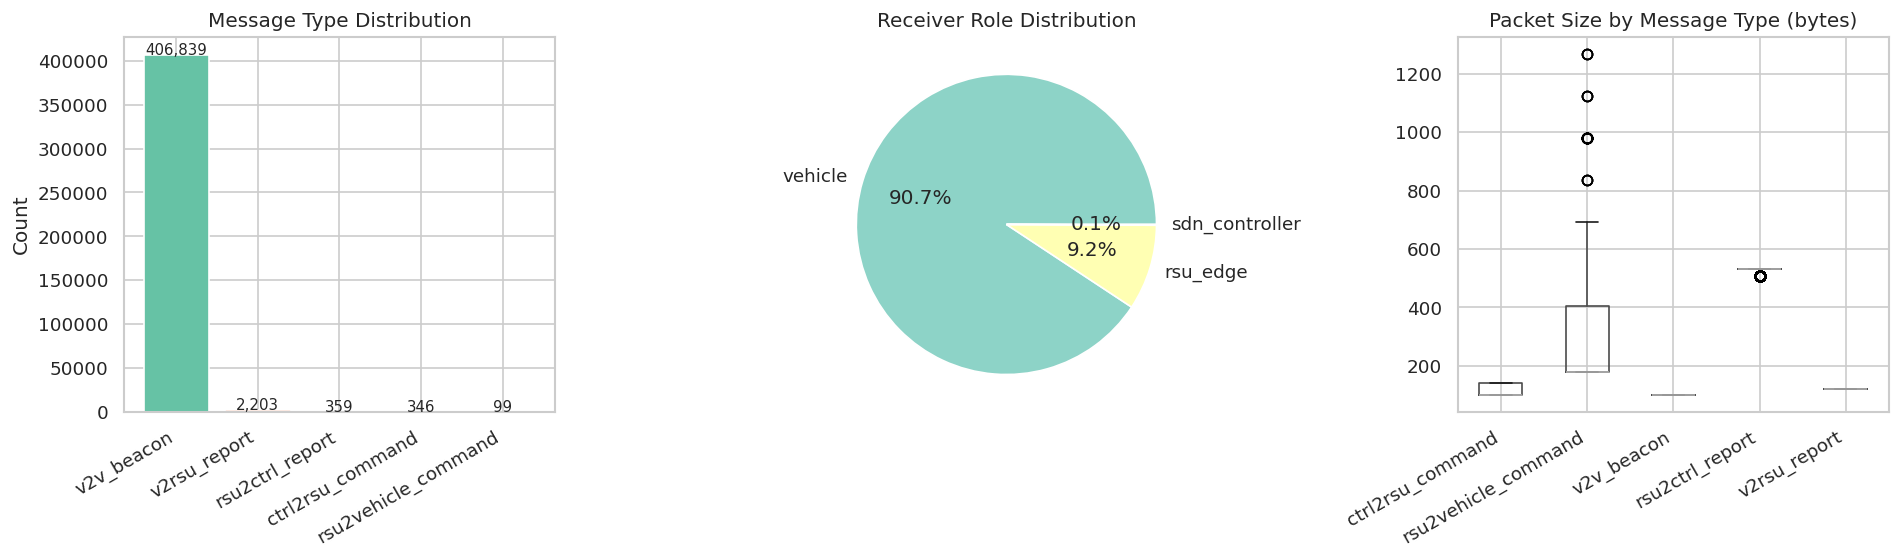

                     min  median   max
msg_label                             
ctrl2rsu_command     100   100.0   140
rsu2ctrl_report      180   180.0  1268
rsu2vehicle_command  100   100.0   100
v2rsu_report         508   533.0   533
v2v_beacon           120   120.0   120


In [4]:
MSG_LABELS = {1: 'v2v_beacon', 2: 'v2rsu_report', 3: 'rsu2ctrl_report',
              4: 'ctrl2rsu_command', 5: 'rsu2vehicle_command'}
df['msg_label'] = df['message_type'].map(MSG_LABELS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Message type counts
mt = df['msg_label'].value_counts()
axes[0].bar(range(len(mt)), mt.values, color=sns.color_palette('Set2', len(mt)))
axes[0].set_xticks(range(len(mt)))
axes[0].set_xticklabels(mt.index, rotation=30, ha='right')
axes[0].set_title('Message Type Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(mt.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Receiver role
rr = df['receiver_role'].value_counts()
axes[1].pie(rr.values, labels=rr.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(rr)))
axes[1].set_title('Receiver Role Distribution')

# Packet sizes per message type
order = df.groupby('msg_label')['packet_size'].median().sort_values().index
df.boxplot(column='packet_size', by='msg_label', ax=axes[2],
           positions=range(len(order)), )
axes[2].set_xticklabels(order, rotation=30, ha='right')
axes[2].set_title('Packet Size by Message Type (bytes)')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()
print(df.groupby('msg_label')['packet_size'].agg(['min','median','max']))

## 4. Sybil Detection Indicators

Legitimate transmissions : 290,796  (71.0%)
Sybil transmissions      : 119,050  (29.0%)



,msg_label,total_count,sybil_count,sybil_pct
0,ctrl2rsu_command,346,0.0,0.0
1,rsu2ctrl_report,359,0.0,0.0
2,rsu2vehicle_command,99,0.0,0.0
3,v2rsu_report,2203,501.0,22.7
4,v2v_beacon,406839,118549.0,29.1


/tmp/ipykernel_235475/2722268725.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(merged['msg_label'], rotation=30, ha='right')


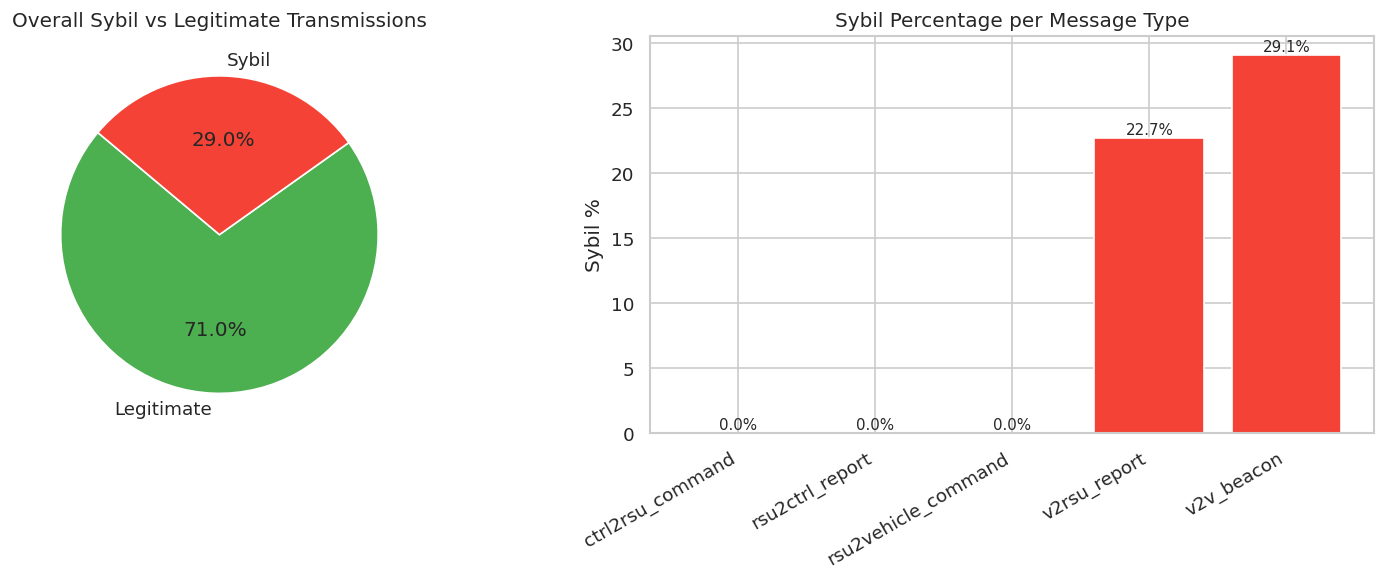

In [5]:
# A row is a Sybil transmission when real_node_id != claimed_node_id
df['is_sybil'] = df['real_node_id'] != df['claimed_node_id']

sybil_total   = df['is_sybil'].sum()
legit_total   = (~df['is_sybil']).sum()
sybil_pct     = 100 * sybil_total / len(df)

print(f'Legitimate transmissions : {legit_total:,}  ({100-sybil_pct:.1f}%)')
print(f'Sybil transmissions      : {sybil_total:,}  ({sybil_pct:.1f}%)')
print()

# Sybil breakdown by message type
sybil_by_type = df[df['is_sybil']].groupby('msg_label').size().reset_index(name='sybil_count')
total_by_type = df.groupby('msg_label').size().reset_index(name='total_count')
merged = total_by_type.merge(sybil_by_type, on='msg_label', how='left').fillna(0)
merged['sybil_pct'] = (100 * merged['sybil_count'] / merged['total_count']).round(1)
display(merged)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([legit_total, sybil_total], labels=['Legitimate', 'Sybil'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=140)
axes[0].set_title('Overall Sybil vs Legitimate Transmissions')

bars = axes[1].bar(merged['msg_label'], merged['sybil_pct'],
                   color=['#F44336' if p > 0 else '#4CAF50' for p in merged['sybil_pct']])
axes[1].set_xticklabels(merged['msg_label'], rotation=30, ha='right')
axes[1].set_ylabel('Sybil %')
axes[1].set_title('Sybil Percentage per Message Type')
for bar, val in zip(bars, merged['sybil_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Sybil Activity Over Time

ValueError: 'y1' is not 1-dimensional

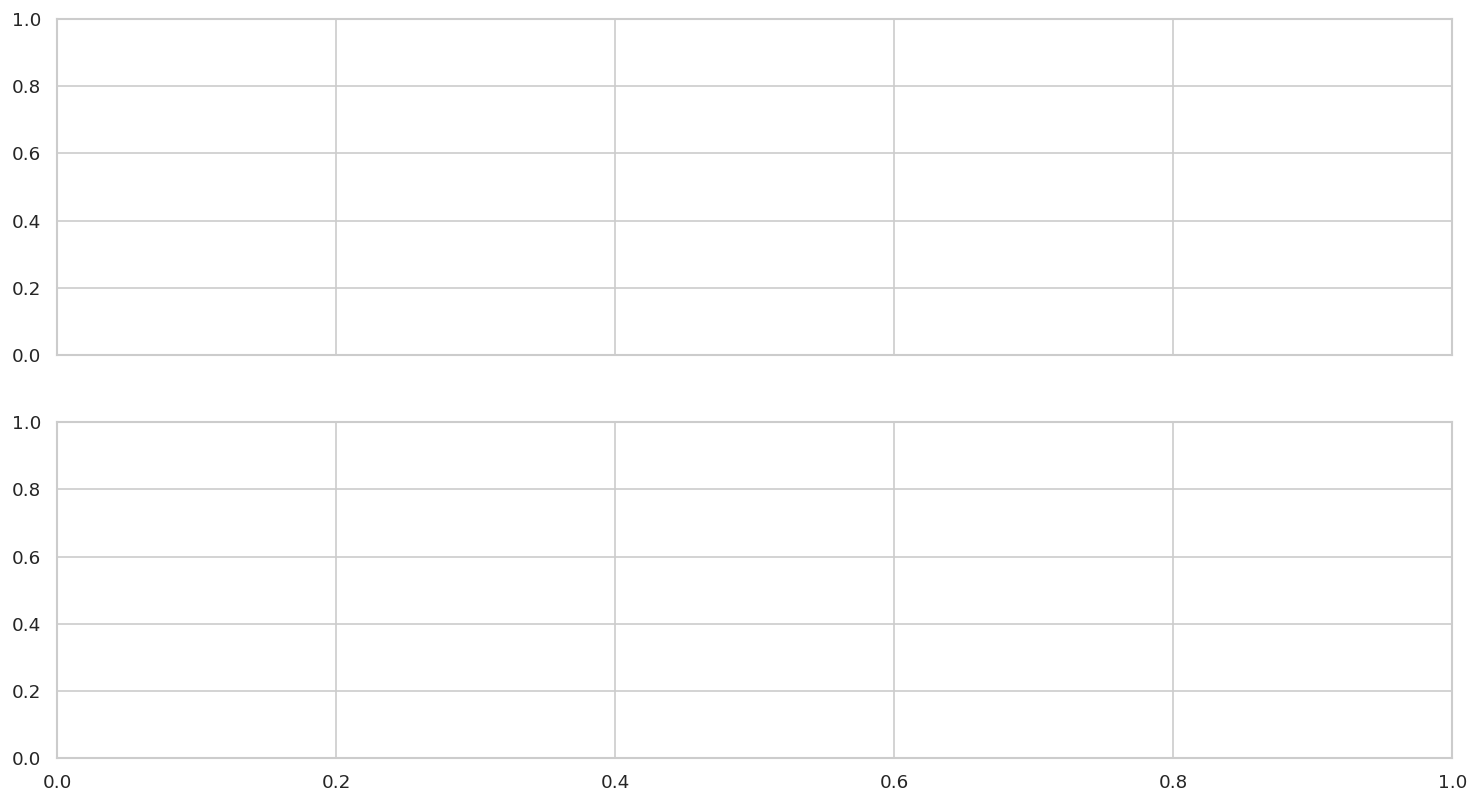

In [6]:
# Bin time into 1-second windows
df['time_bin'] = df['receive_time'].round(0).astype(int)

timeline = df.groupby(['time_bin', 'is_sybil']).size().unstack(fill_value=0)
timeline.columns = ['legitimate', 'sybil'] if False in timeline.columns else timeline.columns
if True not in timeline.columns:
    timeline[True] = 0
if False not in timeline.columns:
    timeline[False] = 0
timeline = timeline.rename(columns={False: 'legitimate', True: 'sybil'})

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].fill_between(timeline.index, timeline['legitimate'], alpha=0.7, color='#4CAF50', label='Legitimate')
axes[0].fill_between(timeline.index, timeline['sybil'], alpha=0.8, color='#F44336', label='Sybil')
axes[0].set_ylabel('Packets / second')
axes[0].set_title('Network Traffic Over Time (1s bins)')
axes[0].legend()

sybil_ratio = timeline['sybil'] / (timeline['legitimate'] + timeline['sybil'] + 1e-9)
axes[1].plot(timeline.index, sybil_ratio * 100, color='#F44336', linewidth=1.2)
axes[1].axhline(sybil_ratio.mean() * 100, color='gray', linestyle='--', label=f'Mean {sybil_ratio.mean()*100:.1f}%')
axes[1].set_ylabel('Sybil traffic %')
axes[1].set_xlabel('Simulation time (s)')
axes[1].set_title('Sybil Traffic Ratio Over Time')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Sybil Vehicles — Identity Mapping

In [ ]:
# Which real nodes transmit as which claimed IDs (Sybil identity mapping)
sybil_df = df[df['is_sybil'] & (df['message_type'] == 1)]

identity_map = (sybil_df.groupby(['real_node_id', 'claimed_node_id'])
                         .size()
                         .reset_index(name='beacon_count')
                         .sort_values('beacon_count', ascending=False))

print(f'Sybil identity pairs: {len(identity_map)}')
display(identity_map.head(20))

# How many fake identities each sybil node adopts
ids_per_attacker = identity_map.groupby('real_node_id')['claimed_node_id'].nunique()
print(f'\nFake identities per attacker node:')
display(ids_per_attacker.value_counts().sort_index().rename('attacker_count'))

In [ ]:
# Beacon count per real node (compare attackers vs legitimate nodes)
beacons = df[df['message_type'] == 1]
per_node = beacons.groupby(['real_node_id', 'is_sybil'])['sequence_number'].count().reset_index()
per_node.columns = ['real_node_id', 'is_sybil', 'beacon_count']

fig, ax = plt.subplots(figsize=(12, 4))
for sybil_flag, color, label in [(False, '#4CAF50', 'Legitimate'), (True, '#F44336', 'Sybil attacker')]:
    subset = per_node[per_node['is_sybil'] == sybil_flag]
    ax.scatter(subset['real_node_id'], subset['beacon_count'],
               c=color, alpha=0.7, s=20, label=label)
ax.set_xlabel('Real Node ID')
ax.set_ylabel('Total beacons sent')
ax.set_title('Beacon Count per Vehicle (Sybil attackers send more because of fake IDs)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Delay Analysis

In [ ]:
delay_ms = df.copy()
delay_ms['delay_ms'] = delay_ms['delay'] * 1000

# Delay stats by message type
delay_stats = (delay_ms.groupby('msg_label')['delay_ms']
               .agg(['mean', 'median', 'std', 'max'])
               .round(3)
               .sort_values('mean'))
display(delay_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF of v2v beacon delay
v2v_delay = delay_ms[delay_ms['message_type'] == 1]['delay_ms'].sort_values()
axes[0].plot(v2v_delay.values, np.linspace(0, 1, len(v2v_delay)), color='steelblue')
axes[0].set_xlabel('Delay (ms)')
axes[0].set_ylabel('CDF')
axes[0].set_title('v2v_beacon Delay CDF')
axes[0].axvline(v2v_delay.median(), color='red', linestyle='--',
                label=f'Median {v2v_delay.median():.2f} ms')
axes[0].legend()

# Delay by type (violin)
plot_types = delay_ms[delay_ms['delay_ms'] < delay_ms['delay_ms'].quantile(0.995)]
plot_types.boxplot(column='delay_ms', by='msg_label', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Delay Distribution by Message Type (ms)')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 8. Vehicle Position Heatmap (BSM Location Data)

In [ ]:
# Only v2v beacons carry valid position (bsm_x, bsm_y)
pos_df = df[(df['message_type'] == 1) & (df['bsm_x'] > 0) & (df['bsm_y'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# All vehicles
axes[0].hexbin(pos_df['bsm_x'], pos_df['bsm_y'], gridsize=50,
               cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('X position (m)')
axes[0].set_ylabel('Y position (m)')
axes[0].set_title('Vehicle Position Heatmap (all beacons)')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='Beacon count')

# Sybil vs legitimate positions
legit_pos  = pos_df[~pos_df['is_sybil']]
sybil_pos  = pos_df[ pos_df['is_sybil']]
axes[1].scatter(legit_pos['bsm_x'], legit_pos['bsm_y'],
                c='#4CAF50', alpha=0.2, s=2, label='Legitimate')
axes[1].scatter(sybil_pos['bsm_x'], sybil_pos['bsm_y'],
                c='#F44336', alpha=0.4, s=4, label='Sybil')
axes[1].set_xlabel('X position (m)')
axes[1].set_ylabel('Y position (m)')
axes[1].set_title('Sybil vs Legitimate Positions')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

print(f'Beacons with valid position: {len(pos_df):,} of {len(df[df["message_type"]==1]):,} v2v beacons')

## 9. BSM Speed and Heading Analysis

In [ ]:
moving = df[(df['message_type'] == 1) & (df['bsm_speed'] > 0.01)]
static = df[(df['message_type'] == 1) & (df['bsm_speed'] <= 0.01)]

print(f'Beacons with speed > 0 (SUMO moving vehicles): {len(moving):,}')
print(f'Beacons with speed = 0 (static / mode 1-2 runs): {len(static):,}')

if len(moving) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(moving['bsm_speed'], bins=40, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Speed (m/s)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'BSM Speed Distribution (moving vehicles, n={len(moving):,})')
    axes[0].axvline(moving['bsm_speed'].mean(), color='red', linestyle='--',
                    label=f"Mean {moving['bsm_speed'].mean():.1f} m/s")
    axes[0].legend()

    # Heading rose chart
    ax_polar = plt.subplot(122, projection='polar')
    angles = np.radians(moving['bsm_heading'])
    ax_polar.hist(angles, bins=36, color='steelblue', alpha=0.7)
    ax_polar.set_title('BSM Heading Distribution (degrees)', pad=15)
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)

    plt.tight_layout()
    plt.show()
    display(moving['bsm_speed'].describe().round(2))
else:
    print('No moving vehicle data in this log. Re-run simulation with mobility_mode=5 to populate speed/heading.')

## 10. V2RSU Report Analysis

In [ ]:
v2rsu = df[df['message_type'] == 2].copy()
print(f'V2RSU reports: {len(v2rsu):,}')
print()

if len(v2rsu) > 0:
    display(v2rsu[['v2rsu_neighbor_count', 'v2rsu_suspicious_count',
                    'v2rsu_window_start', 'v2rsu_window_end']].describe().round(2))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(v2rsu['v2rsu_neighbor_count'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Neighbor count')
    axes[0].set_title('Neighbors Seen per Report Window')

    axes[1].hist(v2rsu['v2rsu_suspicious_count'], bins=20, color='#F44336', edgecolor='white')
    axes[1].set_xlabel('Suspicious count')
    axes[1].set_title('Suspicious Vehicles per Report Window')

    # Suspicious ratio
    v2rsu['susp_ratio'] = v2rsu['v2rsu_suspicious_count'] / (v2rsu['v2rsu_neighbor_count'] + 1e-9)
    axes[2].scatter(v2rsu['receive_time'], v2rsu['susp_ratio'] * 100,
                    alpha=0.5, s=10, color='#FF9800')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Suspicious %')
    axes[2].set_title('Suspicious Ratio in Reports Over Time')

    plt.tight_layout()
    plt.show()

## 11. RSU Activity Analysis

In [ ]:
# Beacons received per RSU
rsu_rx = df[(df['receiver_role'] == 'rsu_edge') & (df['message_type'] == 1)]

beacons_per_rsu = rsu_rx.groupby('receiver_id').size().sort_values(ascending=False)
sybil_per_rsu   = rsu_rx[rsu_rx['is_sybil']].groupby('receiver_id').size()

rsu_summary = pd.DataFrame({
    'total_beacons': beacons_per_rsu,
    'sybil_beacons': sybil_per_rsu
}).fillna(0).astype(int)
rsu_summary['sybil_pct'] = (100 * rsu_summary['sybil_beacons'] / rsu_summary['total_beacons']).round(1)
print(f'Active RSUs: {len(rsu_summary)}')
display(rsu_summary.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(rsu_summary.index.astype(str),
            rsu_summary['total_beacons'], color='steelblue', alpha=0.8, label='Legitimate')
axes[0].bar(rsu_summary.index.astype(str),
            rsu_summary['sybil_beacons'], color='#F44336', alpha=0.8, label='Sybil')
axes[0].set_xlabel('RSU ID')
axes[0].set_ylabel('Beacons received')
axes[0].set_title('Beacons Received per RSU')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(rsu_summary.index.astype(str), rsu_summary['sybil_pct'], color='#F44336')
axes[1].set_xlabel('RSU ID')
axes[1].set_ylabel('Sybil %')
axes[1].set_title('Sybil Traffic Percentage per RSU')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Sequence Number Analysis (Duplicate / Burst Detection)

In [ ]:
# For each claimed_node_id, look at sequence number gaps — Sybil Type3 fires bursts
beacons = df[df['message_type'] == 1].copy()
beacons = beacons.sort_values(['claimed_node_id', 'receive_time'])

beacons['seq_gap'] = beacons.groupby('claimed_node_id')['sequence_number'].diff()
beacons['time_gap'] = beacons.groupby('claimed_node_id')['receive_time'].diff()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sybil_flag, color, label in [(False, '#4CAF50', 'Legitimate'), (True, '#F44336', 'Sybil')]:
    sub = beacons[beacons['is_sybil'] == sybil_flag]['time_gap'].dropna()
    sub_ms = sub * 1000
    sub_ms = sub_ms[sub_ms < sub_ms.quantile(0.99)]
    axes[0].hist(sub_ms, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Inter-beacon gap (ms)')
axes[0].set_ylabel('Density')
axes[0].set_title('Inter-beacon Time Gap Distribution')
axes[0].legend()

# Simultaneous beacons (same claimed_node_id, same time window <100ms)
beacons['time_rounded'] = (beacons['receive_time'] * 10).round() / 10
simultaneous = (beacons.groupby(['claimed_node_id', 'time_rounded'])
                        .size().reset_index(name='count'))
multi = simultaneous[simultaneous['count'] > 1]
axes[1].hist(multi['count'], bins=range(2, multi['count'].max() + 2),
             color='#FF9800', edgecolor='white')
axes[1].set_xlabel('Beacons per 100ms window per claimed ID')
axes[1].set_ylabel('Windows count')
axes[1].set_title(f'Simultaneous Beacon Windows (count={len(multi):,})')

plt.tight_layout()
plt.show()

## 13. Per-Vehicle Summary Table

In [ ]:
vehicle_summary = (
    df[df['message_type'] == 1]
    .groupby('real_node_id')
    .agg(
        total_beacons       =('sequence_number', 'count'),
        sybil_beacons       =('is_sybil', 'sum'),
        unique_claimed_ids  =('claimed_node_id', 'nunique'),
        first_seen          =('receive_time', 'min'),
        last_seen           =('receive_time', 'max'),
        mean_speed          =('bsm_speed', 'mean'),
        mean_delay_ms       =('delay', lambda x: x.mean() * 1000),
    )
    .reset_index()
)
vehicle_summary['is_sybil_node'] = vehicle_summary['sybil_beacons'] > 0
vehicle_summary['active_duration'] = vehicle_summary['last_seen'] - vehicle_summary['first_seen']
vehicle_summary = vehicle_summary.round(3)

print(f"Total vehicles: {len(vehicle_summary)}")
print(f"Sybil attacker nodes: {vehicle_summary['is_sybil_node'].sum()}")
print(f"Legitimate nodes: {(~vehicle_summary['is_sybil_node']).sum()}")
print()
display(vehicle_summary.sort_values('sybil_beacons', ascending=False).head(20))

## 14. SDN Controller — Trust Score and Suspicion Flags

In [ ]:
# RSU→Controller reports carry trust_score and suspicion_flags
rsu2ctrl = df[df['message_type'] == 3].copy()
print(f'RSU→Controller reports: {len(rsu2ctrl):,}')

if len(rsu2ctrl) > 0 and rsu2ctrl['rsu2sdn_trust_score'].sum() > 0:
    display(rsu2ctrl[['rsu2sdn_trust_score', 'rsu2sdn_suspicion_flags',
                        'rsu2sdn_observer_count', 'rsu2sdn_report_count']].describe().round(3))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(rsu2ctrl['rsu2sdn_trust_score'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Trust score')
    axes[0].set_title('Trust Score Distribution in Reports')

    axes[1].hist(rsu2ctrl['rsu2sdn_suspicion_flags'].astype(str), color='#FF9800')
    axes[1].set_xlabel('Suspicion flags')
    axes[1].set_title('Suspicion Flag Values')

    # Trust score vs real vs claimed
    rsu2ctrl['is_sybil_report'] = rsu2ctrl['real_node_id'] != rsu2ctrl['rsu2sdn_claimed_vehicle_id']
    for flag, color, label in [(False, '#4CAF50', 'Legitimate'), (True, '#F44336', 'Sybil')]:
        sub = rsu2ctrl[rsu2ctrl['is_sybil_report'] == flag]
        axes[2].scatter(sub['receive_time'], sub['rsu2sdn_trust_score'],
                        c=color, alpha=0.5, s=12, label=label)
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Trust score')
    axes[2].set_title('Trust Score Over Time')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Trust score not populated yet (solution_mode=6 / no detection run).')
    print('Run with solution_mode=5 to populate trust scores.')

## 15. Full Summary Report

In [ ]:
total = len(df)
beacons_total  = (df['message_type'] == 1).sum()
sybil_total    = df['is_sybil'].sum()
unique_legit   = df[~df['is_sybil']]['real_node_id'].nunique()
unique_sybil   = df[df['is_sybil']]['real_node_id'].nunique()
v2v_delay_med  = df[df['message_type']==1]['delay'].median() * 1000
active_rsus    = df[df['receiver_role']=='rsu_edge']['receiver_id'].nunique()
sim_duration   = df['receive_time'].max() - df['receive_time'].min()

print("=" * 55)
print("  COMMUNICATION LOG — SUMMARY REPORT")
print("=" * 55)
print(f"  Total rows              : {total:>10,}")
print(f"  Simulation duration     : {sim_duration:>10.1f} s")
print(f"  v2v beacons             : {beacons_total:>10,} ({100*beacons_total/total:.1f}%)")
print(f"  Sybil transmissions     : {sybil_total:>10,} ({100*sybil_total/total:.1f}%)")
print(f"  Legitimate node count   : {unique_legit:>10}")
print(f"  Sybil attacker count    : {unique_sybil:>10}")
print(f"  Active RSUs             : {active_rsus:>10}")
print(f"  Median v2v delay        : {v2v_delay_med:>10.3f} ms")
print(f"  Moving vehicle beacons  : {(df['bsm_speed']>0).sum():>10,}")
print("=" * 55)